In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/credit_risk_dataset.csv")

# 02 - Feature Exploration

This notebook performs a deeper exploration of the dataset's features. 
While the previous notebook (01 — Data Understanding) focused on basic 
structure, missing values, and initial visual checks, this notebook 
examines distributions, skewness, outliers, and relationships between 
key variables. These insights prepare the dataset for risk segmentation 
in the next phase. 

## 2.1 Distribution & Outlier Analysis

This section explores the distributions and outliers of key numeric features. 
Understanding skewness and extreme values is essential before segmentation. 

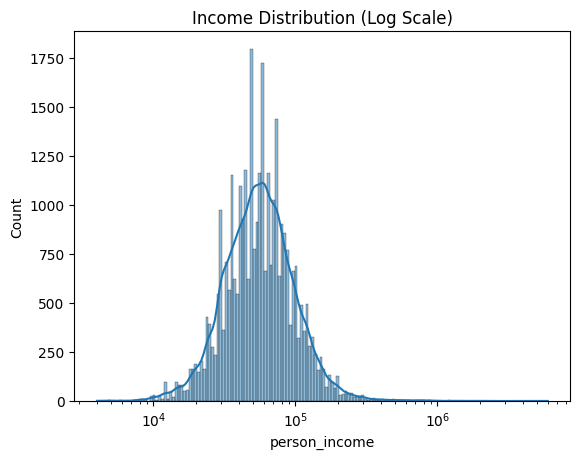

In [19]:
sns.histplot(df["person_income"], log_scale=True, kde=True)
plt.title("Income Distribution (Log Scale)")
plt.show()

Income is extremely skewed with outliers up to ~6,000,000. Log-scaling reveals 
the underlying distribution more clearly and prevents the plot from collapsing 
near zero.

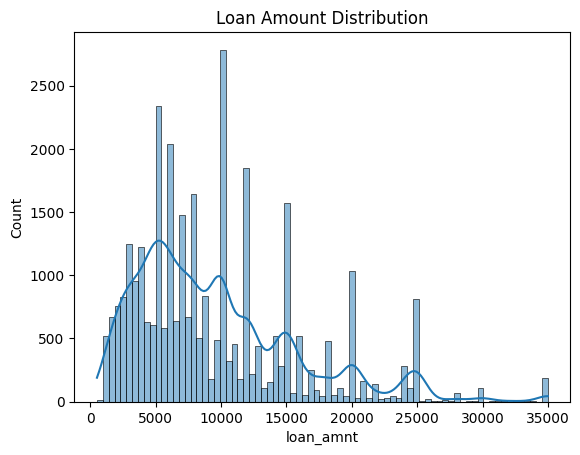

In [20]:
sns.histplot(df["loan_amnt"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

Loan amounts have a more compact distribution with fewer extreme outliers. 
This variable will be useful for segmentation based on loan size.

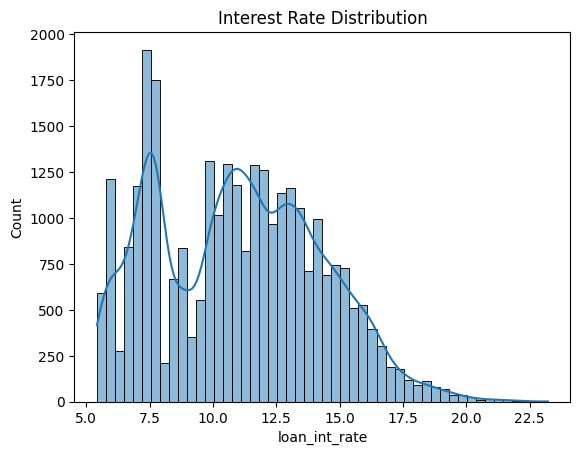

In [21]:
sns.histplot(df["loan_int_rate"], kde=True)
plt.title("Interest Rate Distribution")
plt.show()

Interest rates are concentrated between 5% and 20%, forming a relatively 
regular distribution. This feature may correlate with loan grade and risk.

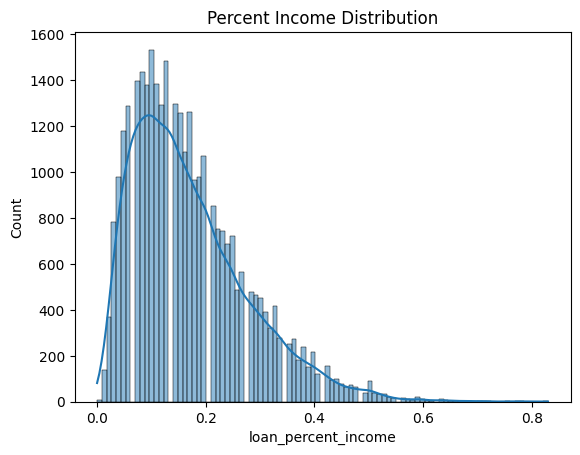

In [22]:
sns.histplot(df["loan_percent_income"], kde=True)
plt.title("Percent Income Distribution")
plt.show()

Percent income measures how large the loan is relative to the applicant's 
income. This variable is important for identifying financially stressed 
segments.

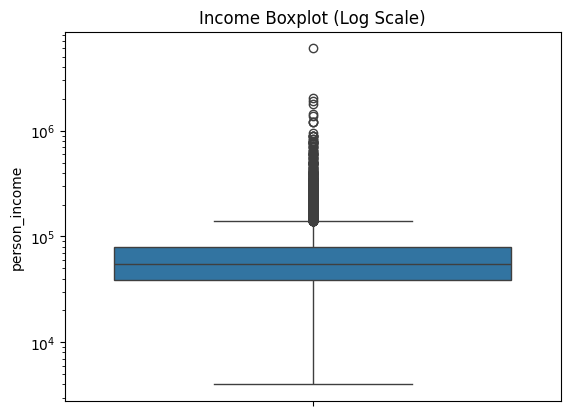

In [23]:
sns.boxplot(data=df, y="person_income")
plt.yscale("log")
plt.title("Income Boxplot (Log Scale)")
plt.show()

The log-scale boxplot shows the median income and the spread of values without 
being dominated by extreme outliers. This confirms the heavy skew observed in 
the histogram.

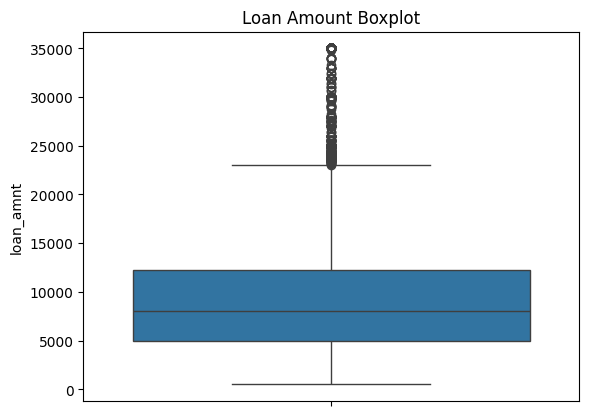

In [24]:
sns.boxplot(data=df, y="loan_amnt")
plt.title("Loan Amount Boxplot")
plt.show()

Loan amounts show a tighter distribution with fewer extreme values. This 
supports the histogram findings and indicates that loan size segmentation 
will be straightforward.

In [25]:
df[["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]].describe()

,person_income,loan_amnt,loan_int_rate,loan_percent_income
count,3.258100e+04,32581.000000,29465.000000,32581.000000
mean,6.607485e+04,9589.371106,11.011695,0.170203
std,6.198312e+04,6322.086646,3.240459,0.106782
min,4.000000e+03,500.000000,5.420000,0.000000
25%,3.850000e+04,5000.000000,7.900000,0.090000
50%,5.500000e+04,8000.000000,10.990000,0.150000
75%,7.920000e+04,12200.000000,13.470000,0.230000
max,6.000000e+06,35000.000000,23.220000,0.830000


The descriptive statistics confirm skewness in income and percent_income. 
The maximum income value (~6M) is far above the upper quartile, indicating 
extreme outliers. These observations guide segmentation decisions in the 
next phase.

### Summary

Income is heavily skewed and requires log-scale visualization due to extreme 
outliers. Percent_income is also skewed, but its range is much narrower and 
does not require log-scaling. Loan amount and interest rate have more regular 
distributions. These findings will be used to design meaningful risk segments 
in the next phase.